# 01 — Strategy performance (SPY, out-of-sample)

Loads the outputs of `experiments/run_regime_comparison.py configs/comparison_spy.yaml` and visualizes net performance. No core logic here — figures come from `regimelab.plotting`.

All series are **out-of-sample** (walk-forward refits) and **net of 5 bps proportional costs**.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from regimelab import plotting

FIG = ROOT / "reports" / "figures"
OUT = ROOT / "experiments" / "outputs" / "comparison_spy"
net = pd.read_csv(OUT / "net_returns.csv", index_col=0, parse_dates=True)
summary = pd.read_csv(OUT / "summary.csv", index_col=0)
net.columns.tolist()

['buy_and_hold',
 'trend_200d',
 'vol20q80_bh',
 'vol20q80_trend',
 'hmm2_bh',
 'hmm2_trend',
 'hmm2p_bh',
 'hmm3_bh',
 'hmm3_trend']

In [2]:
# Headline table at the 5 bps cost level, best Sharpe first.
at5 = summary.loc[summary.index.str.endswith("@5bps")].copy()
at5.index = at5.index.str.replace("@5bps", "")
at5[["ann_return", "ann_volatility", "sharpe", "sortino", "max_drawdown",
     "hit_ratio", "avg_annual_turnover"]].sort_values("sharpe", ascending=False).round(3)

,ann_return,ann_volatility,sharpe,sortino,max_drawdown,hit_ratio,avg_annual_turnover
strategy,,,,,,,
vol20q80_bh,0.101,0.128,0.818,1.128,-0.337,0.554,3.414
hmm2_bh,0.090,0.114,0.812,1.129,-0.229,0.545,9.354
hmm2p_bh,0.084,0.108,0.803,1.113,-0.234,0.533,11.217
hmm2_trend,0.077,0.103,0.778,1.076,-0.191,0.546,7.857
vol20q80_trend,0.082,0.111,0.768,1.055,-0.224,0.550,5.940
hmm3_trend,0.079,0.115,0.723,0.986,-0.215,0.549,6.314
trend_200d,0.080,0.116,0.720,0.981,-0.215,0.549,6.314
hmm3_bh,0.100,0.171,0.645,0.904,-0.518,0.549,4.069
buy_and_hold,0.109,0.190,0.643,0.907,-0.552,0.553,0.047


PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_wealth.png')

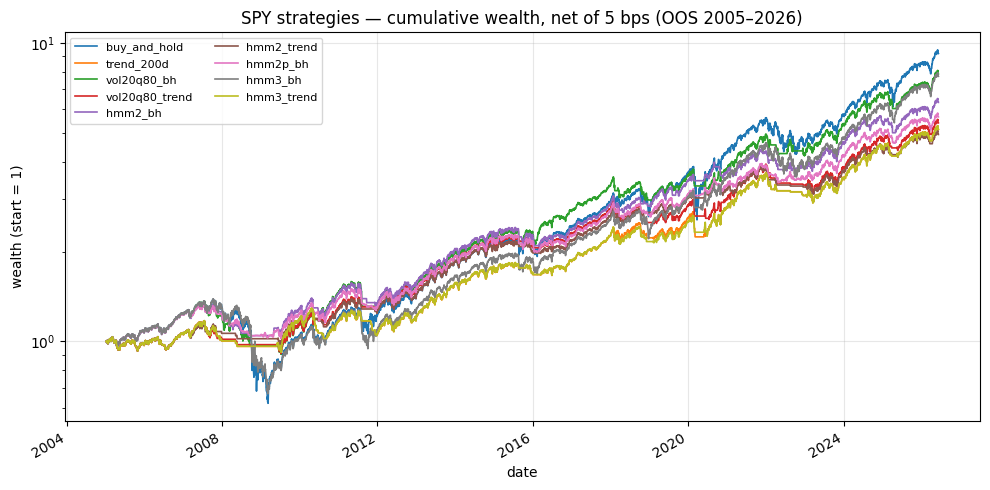

In [3]:
fig = plotting.wealth_curves(net, title="SPY strategies — cumulative wealth, net of 5 bps (OOS 2005–2026)")
plotting.save_figure(fig, FIG / "spy_wealth.png")

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_drawdowns.png')

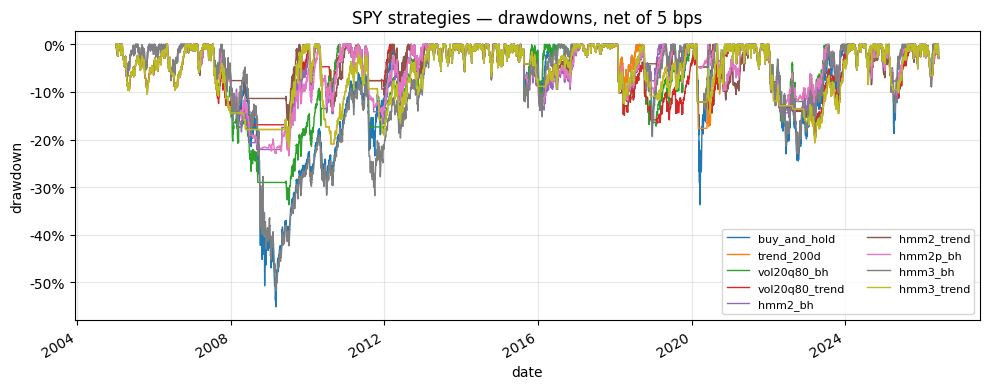

In [4]:
fig = plotting.drawdown_curves(net, title="SPY strategies — drawdowns, net of 5 bps")
plotting.save_figure(fig, FIG / "spy_drawdowns.png")

**Reading.** Gated variants (`vol20q80_bh`, `hmm2_bh`, `hmm2p_bh`) track buy-and-hold in calm markets and step aside in turbulence: similar terminal wealth, much shallower drawdowns (2008-09, 2020, 2022). The 3-state HMM gate (`hmm3_bh`) barely deviates from buy-and-hold — its extreme state fires on only ~2.5% of days. Whether Sharpe differences are statistically meaningful is examined in notebook 03.